In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style professionnel
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Chargement du dataset
df = pd.read_csv(r"E:\Password_Analyzer\data\processed\passwords_features.csv")

print(f"Dataset chargé : {len(df):,} mots de passe, {len(df.columns)} features")
print(f"\nAperçu des colonnes :")
print(df.dtypes)

Dataset chargé : 50,000 mots de passe, 25 features

Aperçu des colonnes :
password                    str
length                    int64
charset_size              int64
entropy                 float64
num_lowercase             int64
num_uppercase             int64
num_digits                int64
num_special               int64
num_unique_chars          int64
ratio_uppercase         float64
ratio_digits            float64
ratio_special           float64
ratio_unique            float64
has_sequential_nums        bool
has_sequential_alpha       bool
has_keyboard_pattern       bool
is_all_same_char           bool
has_date_pattern           bool
starts_with_capital        bool
ends_with_number           bool
ends_with_special          bool
zxcvbn_score              int64
crack_time_seconds      float64
strength_label            int64
strength_name               str
dtype: object


In [2]:
print("=" * 60)
print("STATISTIQUES GÉNÉRALES")
print("=" * 60)
print(df[['length', 'entropy', 'num_unique_chars', 'zxcvbn_score']].describe().round(2))

print(f"\nExemples par catégorie :")
for label in ['Très faible', 'Faible', 'Moyen', 'Fort']:
    sample = df[df['strength_name'] == label]['password'].sample(3, random_state=42).tolist()
    print(f"  {label:12} → {sample}")

STATISTIQUES GÉNÉRALES
         length   entropy  num_unique_chars  zxcvbn_score
count  50000.00  50000.00          50000.00      50000.00
mean       8.75     42.43              7.01          1.99
std        2.40     14.45              1.91          0.92
min        4.00     13.29              2.00          0.00
25%        7.00     32.90              6.00          1.00
50%        8.00     41.36              7.00          2.00
75%       10.00     51.70              8.00          3.00
max       30.00    182.62             21.00          4.00

Exemples par catégorie :
  Très faible  → ['ne00123', '90865324', 'estherjoy']
  Faible       → ['swing244', '[e]ncore', 'waddles11']
  Moyen        → ['cgongtangco', 'mupick2846', 'wawansomad']
  Fort         → ['anela28srpna1994', 'aca48huycuv4', 'c994723181.']


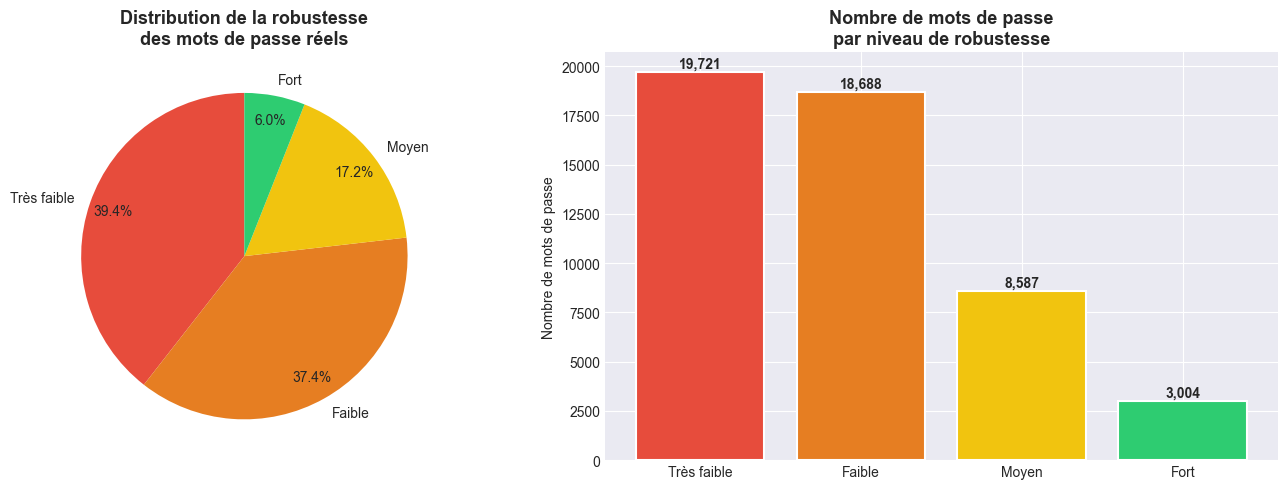

Graphique sauvegardé


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Camembert
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
labels_order = ['Très faible', 'Faible', 'Moyen', 'Fort']
counts = df['strength_name'].value_counts().reindex(labels_order)

axes[0].pie(counts, labels=labels_order, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[0].set_title('Distribution de la robustesse\ndes mots de passe réels', 
                   fontsize=13, fontweight='bold')

# Barres
bars = axes[1].bar(labels_order, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Nombre de mots de passe\npar niveau de robustesse', 
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de mots de passe')
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"E:\Password_Analyzer\reports\figures\01_distribution_robustesse.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

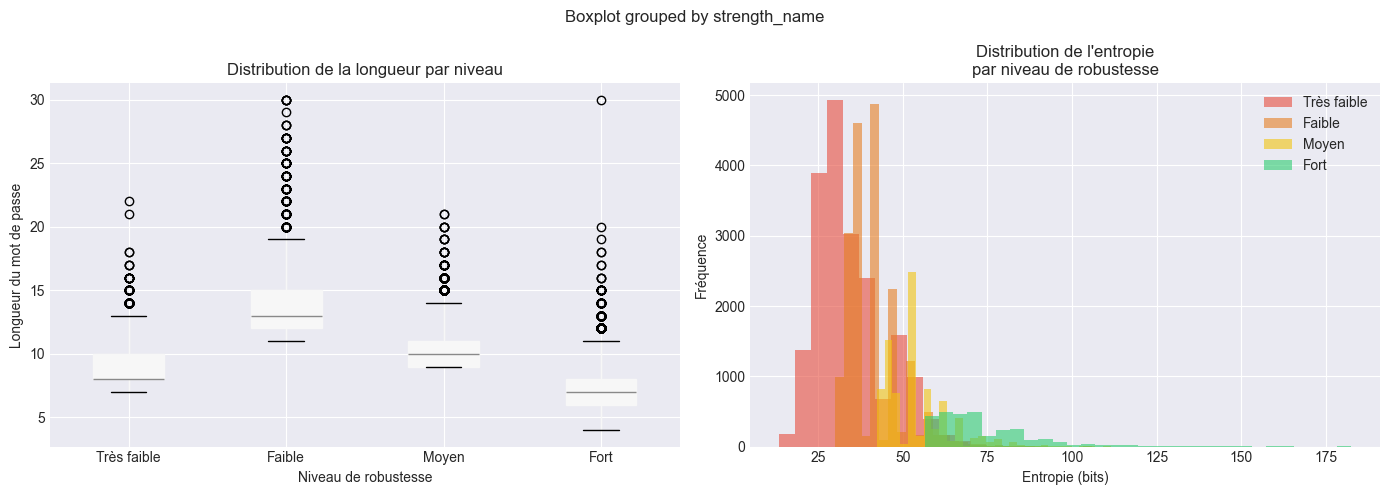

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot longueur par niveau
df.boxplot(column='length', by='strength_name', ax=axes[0],
           positions=range(len(labels_order)),
           patch_artist=True)
axes[0].set_xticklabels(labels_order)
axes[0].set_title('Distribution de la longueur\npar niveau de robustesse')
axes[0].set_xlabel('Niveau de robustesse')
axes[0].set_ylabel('Longueur du mot de passe')
plt.sca(axes[0])
plt.title('Distribution de la longueur par niveau')

# Histogramme entropie
for label, color in zip(labels_order, colors):
    subset = df[df['strength_name'] == label]['entropy']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_title('Distribution de l\'entropie\npar niveau de robustesse')
axes[1].set_xlabel('Entropie (bits)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.savefig(r"E:\Password_Analyzer\reports\figures\02_longueur_entropie.png",
            dpi=150, bbox_inches='tight')
plt.show()

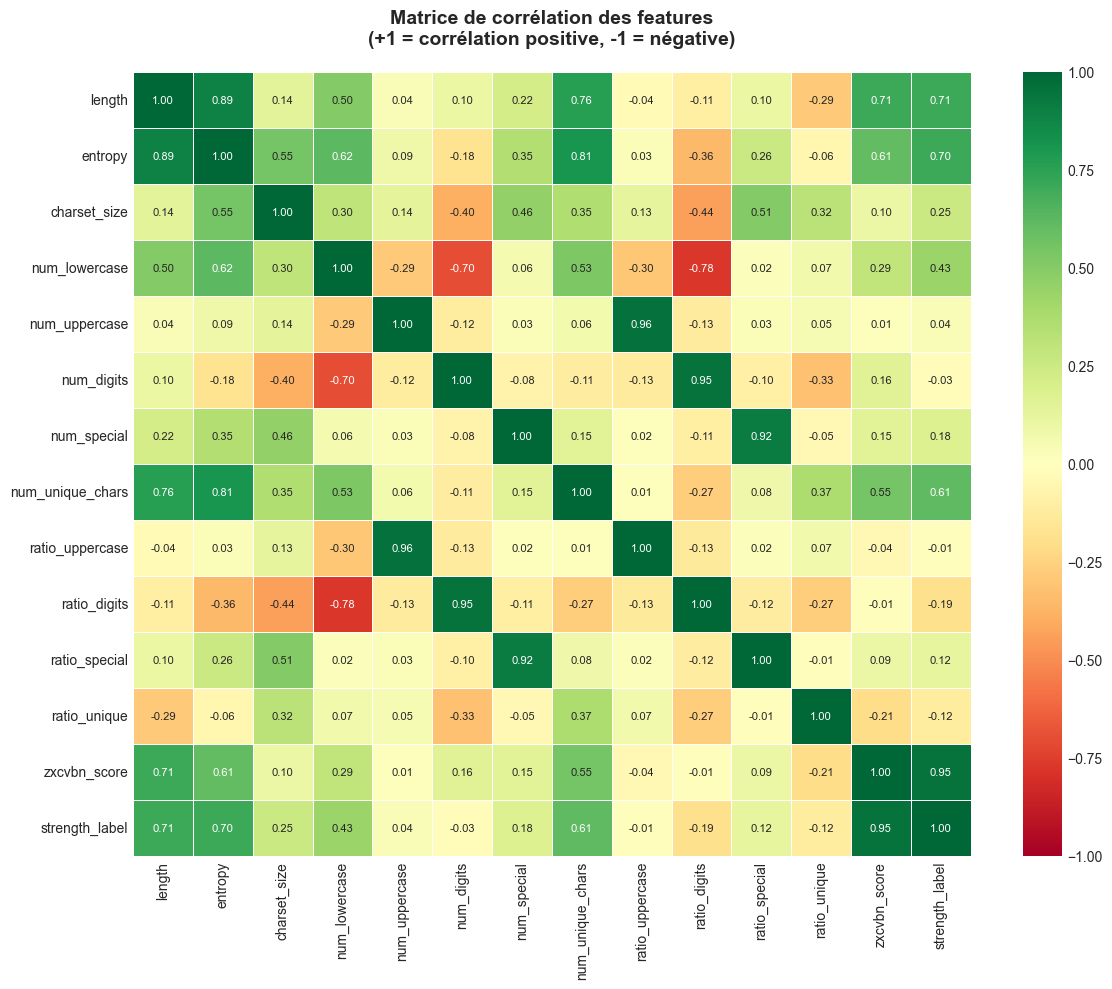

Heatmap sauvegardée


In [5]:
# Sélection des features numériques
numeric_features = ['length', 'entropy', 'charset_size', 'num_lowercase', 
                    'num_uppercase', 'num_digits', 'num_special', 'num_unique_chars',
                    'ratio_uppercase', 'ratio_digits', 'ratio_special', 'ratio_unique',
                    'zxcvbn_score', 'strength_label']

corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix), k=1)  # Masque triangle supérieur

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})

ax.set_title('Matrice de corrélation des features\n(+1 = corrélation positive, -1 = négative)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(r"E:\Password_Analyzer\reports\figures\03_heatmap_correlations.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap sauvegardée")

ANALYSE DES PATTERNS FAIBLES DÉTECTÉS


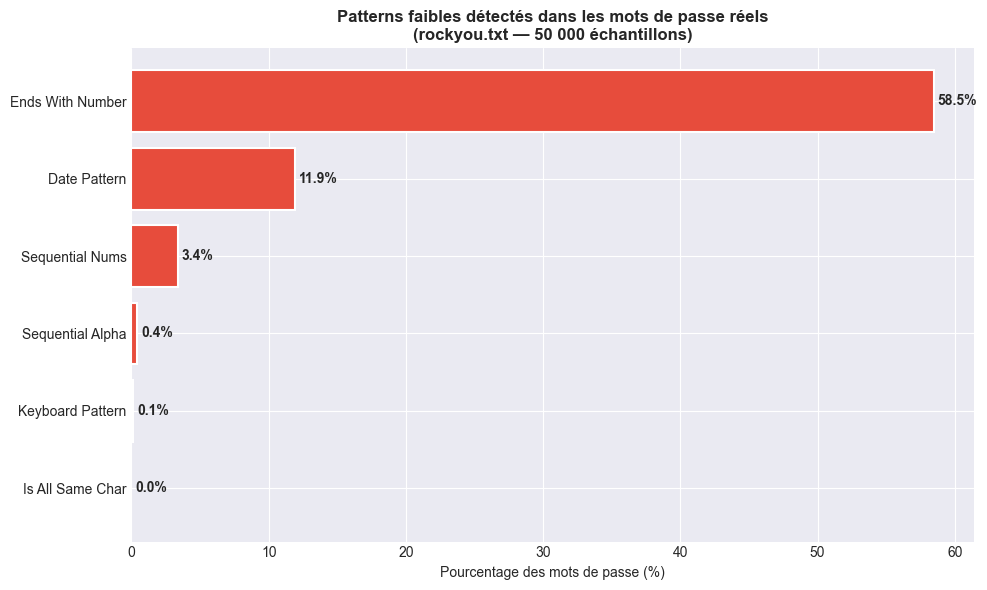

In [6]:
pattern_cols = ['has_sequential_nums', 'has_sequential_alpha', 'has_keyboard_pattern',
                'is_all_same_char', 'has_date_pattern', 'ends_with_number']

print("=" * 60)
print("ANALYSE DES PATTERNS FAIBLES DÉTECTÉS")
print("=" * 60)

pattern_stats = []
for col in pattern_cols:
    total = df[col].sum()
    pct = (total / len(df)) * 100
    pattern_stats.append({'Pattern': col.replace('has_', '').replace('_', ' ').title(),
                          'Occurrences': total, 'Pourcentage': pct})

pattern_df = pd.DataFrame(pattern_stats).sort_values('Pourcentage', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(pattern_df['Pattern'], pattern_df['Pourcentage'], 
               color='#e74c3c', edgecolor='white', linewidth=1.5)
ax.set_xlabel('Pourcentage des mots de passe (%)')
ax.set_title('Patterns faibles détectés dans les mots de passe réels\n(rockyou.txt — 50 000 échantillons)',
             fontweight='bold')

for bar, pct in zip(bars, pattern_df['Pourcentage']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"E:\Password_Analyzer\reports\figures\04_patterns_faibles.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# 1000 mots de passe anonymisés pour GitHub (pas de vrais mots de passe sensibles)
sample_github = df[['length', 'entropy', 'charset_size', 'num_lowercase', 
                     'num_uppercase', 'num_digits', 'num_special', 'ratio_unique',
                     'zxcvbn_score', 'strength_label', 'strength_name']].sample(1000, random_state=42)

sample_github.to_csv(r"E:\Password_Analyzer\data\samples\passwords_sample_anon.csv", index=False)
print(f"Sample anonymisé sauvegardé pour GitHub (sans les mots de passe réels)")
print(f"   → {len(sample_github)} lignes, {len(sample_github.columns)} colonnes")
print(f"\nBonne pratique : on ne publie JAMAIS les vrais mots de passe sur GitHub")

Sample anonymisé sauvegardé pour GitHub (sans les mots de passe réels)
   → 1000 lignes, 11 colonnes

Bonne pratique : on ne publie JAMAIS les vrais mots de passe sur GitHub
